# Anomaly Detection
**Anomaly detection** (or **outlier detection**) in machine learning is the process of **identifying data points or patterns that deviate significantly from the "norm" of a dataset**. In practice, it’s like finding a needle in a haystack—except the needle is an event that shouldn't be there, like a fraudulent credit card transaction or a failing industrial sensor. In a TinyML context, this is critical because anomalies (like a machine about to fail) are often rare, and sending continuous streams of "normal" data to the cloud is a waste of bandwidth and energy.

Distance-based and mixture-based algorithms are fundamental unsupervised approaches. Distance methods flag points far from their neighbors, while mixture models evaluate points based on their probability of belonging to underlying data distributions. Distance-based methods assume that normal data points exist in dense neighborhoods, while anomalies are isolated and located far away from the majority of the data. Mixture-based algorithms assume that data is generated from a combination of several underlying probability distributions (usually Gaussian). The most common approach is the **Gaussian Mixture Model (GMM)**.

## Importing Dataset
Breast cancer datasets provide patient tumor measurements for binary classification (Malignant 'M' or Benign 'B'). Key features include radius, texture, perimeter, area, smoothness, compactness, concavity, and concave points, often totaling 30+ features per sample. 

In [1]:
# Import pandas API
import pandas as pd

# Read the input csv file from UCI Machine Learning Repository
dataset = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data',
                      names=['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 
                             'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
                             'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 
                             'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 
                             'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 
                             'fractal_dimension_worst'])

# Display 10 random samples from the dataset
dataset.sample(10).style.hide(axis="index")

id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
914580,B,12.470000,17.310000,80.450000,480.100000,0.089280,0.076300,0.036090,0.023690,0.152600,0.060460,0.153200,0.781000,1.253000,11.910000,0.003796,0.013710,0.013460,0.007096,0.015360,0.001541,14.060000,24.340000,92.820000,607.300000,0.127600,0.250600,0.202800,0.105300,0.303500,0.076610
859487,B,12.780000,16.490000,81.370000,502.500000,0.098310,0.052340,0.036530,0.028640,0.159000,0.056530,0.236800,0.873200,1.471000,18.330000,0.007962,0.005612,0.015850,0.008662,0.022540,0.001906,13.460000,19.760000,85.670000,554.900000,0.129600,0.070610,0.103900,0.058820,0.238300,0.064100
911201,B,14.530000,13.980000,93.860000,644.200000,0.109900,0.092420,0.068950,0.064950,0.165000,0.061210,0.306000,0.721300,2.143000,25.700000,0.006133,0.012510,0.016150,0.011360,0.022070,0.003563,15.800000,16.930000,103.100000,749.900000,0.134700,0.147800,0.137300,0.106900,0.260600,0.078100
91813702,B,12.340000,12.270000,78.940000,468.500000,0.090030,0.063070,0.029580,0.026470,0.168900,0.058080,0.116600,0.495700,0.771400,8.955000,0.003681,0.009169,0.008732,0.005740,0.011290,0.001366,13.610000,19.270000,87.220000,564.900000,0.129200,0.207400,0.179100,0.107000,0.311000,0.075920
88649001,M,19.550000,28.770000,133.600000,1207.000000,0.092600,0.206300,0.178400,0.114400,0.189300,0.062320,0.842600,1.199000,7.158000,106.400000,0.006356,0.047650,0.038630,0.015190,0.019360,0.005252,25.050000,36.270000,178.600000,1926.000000,0.128100,0.532900,0.425100,0.194100,0.281800,0.100500
916799,M,18.310000,20.580000,120.800000,1052.000000,0.106800,0.124800,0.156900,0.094510,0.186000,0.059410,0.544900,0.922500,3.218000,67.360000,0.006176,0.018770,0.029130,0.010460,0.015590,0.002725,21.860000,26.200000,142.200000,1493.000000,0.149200,0.253600,0.375900,0.151000,0.307400,0.078630
88350402,B,13.640000,15.600000,87.380000,575.300000,0.094230,0.066300,0.047050,0.037310,0.171700,0.056600,0.324200,0.661200,1.996000,27.190000,0.006470,0.012480,0.018100,0.011030,0.018980,0.001794,14.850000,19.050000,94.110000,683.400000,0.127800,0.129100,0.153300,0.092220,0.253000,0.065100
90317302,B,10.260000,12.220000,65.750000,321.600000,0.099960,0.075420,0.019230,0.019680,0.180000,0.065690,0.191100,0.547700,1.348000,11.880000,0.005682,0.013650,0.008496,0.006929,0.019380,0.002371,11.380000,15.650000,73.230000,394.500000,0.134300,0.165000,0.086150,0.066960,0.293700,0.077220
8912284,B,12.890000,15.700000,84.080000,516.600000,0.078180,0.095800,0.111500,0.033900,0.143200,0.059350,0.291300,1.389000,2.347000,23.290000,0.006418,0.039610,0.079270,0.017740,0.018780,0.003696,13.900000,19.690000,92.120000,595.600000,0.099260,0.231700,0.334400,0.101700,0.199900,0.071270
914062,M,18.010000,20.560000,118.400000,1007.000000,0.100100,0.128900,0.117000,0.077620,0.211600,0.060770,0.754800,1.288000,5.353000,89.740000,0.007997,0.027000,0.037370,0.016480,0.028970,0.003996,21.530000,26.060000,143.400000,1426.000000,0.130900,0.232700,0.254400,0.148900,0.325100,0.076250


In [2]:
# Drop the 'id' column as it is not needed for anomaly detection
dataset.drop(columns=['id'], inplace=True)

# Display 10 random samples from the dataset
dataset.sample(10).style.hide(axis="index")

diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
B,13.640000,15.600000,87.380000,575.300000,0.094230,0.066300,0.047050,0.037310,0.171700,0.056600,0.324200,0.661200,1.996000,27.190000,0.006470,0.012480,0.018100,0.011030,0.018980,0.001794,14.850000,19.050000,94.110000,683.400000,0.127800,0.129100,0.153300,0.092220,0.253000,0.065100
M,19.100000,26.290000,129.100000,1132.000000,0.121500,0.179100,0.193700,0.146900,0.163400,0.072240,0.519000,2.910000,5.801000,67.100000,0.007545,0.060500,0.021340,0.018430,0.030560,0.010390,20.330000,32.720000,141.300000,1298.000000,0.139200,0.281700,0.243200,0.184100,0.231100,0.092030
M,17.600000,23.330000,119.000000,980.500000,0.092890,0.200400,0.213600,0.100200,0.169600,0.073690,0.928900,1.465000,5.801000,104.900000,0.006766,0.070250,0.065910,0.023110,0.016730,0.011300,21.570000,28.870000,143.600000,1437.000000,0.120700,0.478500,0.516500,0.199600,0.230100,0.122400
B,9.465000,21.010000,60.110000,269.400000,0.104400,0.077730,0.021720,0.015040,0.171700,0.068990,0.235100,2.011000,1.660000,14.200000,0.010520,0.017550,0.017140,0.009333,0.022790,0.004237,10.410000,31.560000,67.030000,330.700000,0.154800,0.166400,0.094120,0.065170,0.287800,0.092110
M,18.940000,21.310000,123.600000,1130.000000,0.090090,0.102900,0.108000,0.079510,0.158200,0.054610,0.788800,0.797500,5.486000,96.050000,0.004444,0.016520,0.022690,0.013700,0.013860,0.001698,24.860000,26.580000,165.900000,1866.000000,0.119300,0.233600,0.268700,0.178900,0.255100,0.065890
M,12.680000,23.840000,82.690000,499.000000,0.112200,0.126200,0.112800,0.068730,0.190500,0.065900,0.425500,1.178000,2.927000,36.460000,0.007781,0.026480,0.029730,0.012900,0.016350,0.003601,17.090000,33.470000,111.800000,888.300000,0.185100,0.406100,0.402400,0.171600,0.338300,0.103100
M,18.820000,21.970000,123.700000,1110.000000,0.101800,0.138900,0.159400,0.087440,0.194300,0.061320,0.819100,1.931000,4.493000,103.900000,0.008074,0.040880,0.053210,0.018340,0.023830,0.004515,22.660000,30.930000,145.300000,1603.000000,0.139000,0.346300,0.391200,0.170800,0.300700,0.083140
B,14.860000,16.940000,94.890000,673.700000,0.089240,0.070740,0.033460,0.028770,0.157300,0.057030,0.302800,0.668300,1.612000,23.920000,0.005756,0.016650,0.014610,0.008281,0.015510,0.002168,16.310000,20.540000,102.300000,777.500000,0.121800,0.155000,0.122000,0.079710,0.252500,0.068270
B,9.720000,18.220000,60.730000,288.100000,0.069500,0.023440,0.000000,0.000000,0.165300,0.064470,0.353900,4.885000,2.230000,21.690000,0.001713,0.006736,0.000000,0.000000,0.037990,0.001688,9.968000,20.830000,62.250000,303.800000,0.071170,0.027290,0.000000,0.000000,0.190900,0.065590
M,15.340000,14.260000,102.500000,704.400000,0.107300,0.213500,0.207700,0.097560,0.252100,0.070320,0.438800,0.709600,3.384000,44.910000,0.006789,0.053280,0.064460,0.022520,0.036720,0.004394,18.070000,19.080000,125.100000,980.900000,0.139000,0.595400,0.630500,0.239300,0.466700,0.099460


## Ploting Class Distribution
The dataset featuring 569 instances with a binary distribution of 357 (62.7%) benign and 212 (37.3%) malignant cases.

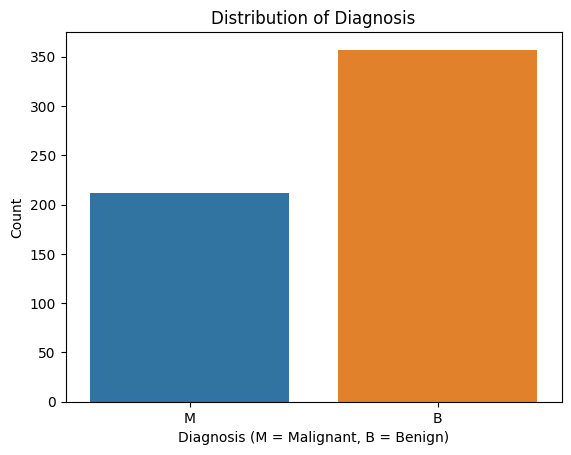

Number of Malignant samples: 212
Number of Benign samples: 357


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
sns.countplot(x='diagnosis', data=dataset, hue='diagnosis')
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')
plt.show()

# Print the number of samples in each class
malignant_count = dataset[dataset['diagnosis'] == 'M'].shape[0]
benign_count = dataset[dataset['diagnosis'] == 'B'].shape[0]
print(f'Number of Malignant samples: {malignant_count}')
print(f'Number of Benign samples: {benign_count}')

## Handling Imbalanced Dataset
**Oversampling** handles imbalanced data by increasing the number of minority class instances to match the majority class. Common methods include random oversampling (duplicating existing instances) and synthetic generation like `SMOTE` (Synthetic Minority Over-sampling Technique). Oversampling works well when the minority class contains unique or important information, but it can lead to overfitting and may not work well with high-dimensional data.

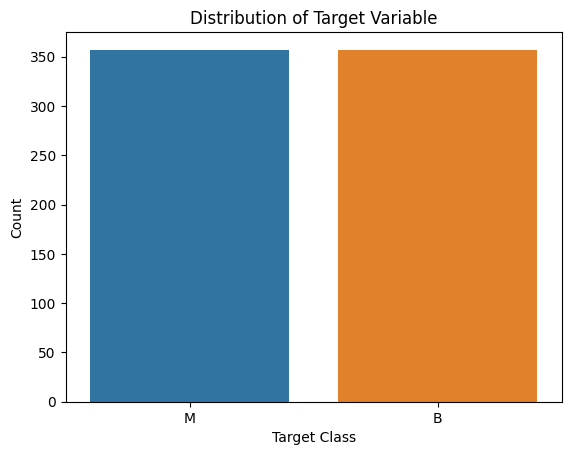

Benign Sample Size,Malignant Sample Size
357,357


In [4]:
from sklearn.utils import resample

# Apply oversampling to the minority class (M samples) to balance the dataset
M_samples = dataset[dataset.iloc[:, 0] == 'M']
B_samples = dataset[dataset.iloc[:, 0] == 'B']
oversampled_M_samples = resample(M_samples, replace=True, n_samples=B_samples.shape[0], random_state=42)

# Combine the oversampled M samples with the B samples to create a balanced dataset
balanced_dataset = pd.concat([oversampled_M_samples, B_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

# Plot the distribution of the target variable
sns.countplot(x=balanced_dataset.iloc[:, 0], hue=balanced_dataset.iloc[:, 0])
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

# Create a dataframe for the class sample sizes
balanced_dataset_samples_df = pd.DataFrame({
    'Benign Sample Size': [balanced_dataset[balanced_dataset.iloc[:, 0] == 'B'].shape[0]],
    'Malignant Sample Size': [balanced_dataset[balanced_dataset.iloc[:, 0] == 'M'].shape[0]]
})

# Display the distribution of the features for good and bad samples
balanced_dataset_samples_df.style.hide(axis="index")

## Preprocessing of Dataset
The **Standard Scaler** is a data preprocessing technique in machine learning that standardizes features by removing the mean and scaling the data to unit variance. This results in a transformed dataset with a mean of zero and a standard deviation of one for each feature.

The formula for the standard score (also known as the z-score) is described below:
$$
z=\frac{x-\mu}{  \sigma}
$$

Where
* $z$ is the scaled, or standardized, value (the z-score).
* $x$ is the original feature value.
* $\mu$ is the mean of the feature's training samples.
* $\sigma$ is the standard deviation of the feature's training samples. 

The primary purpose of the Standard Scaler is to ensure that features with different scales contribute equally to a model's objective function, preventing features with large variances from dominating those with smaller variances.

In [5]:
# Standardize the features before applying PCA
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
features = balanced_dataset.drop(columns=['diagnosis'])
targets = balanced_dataset['diagnosis']

# Standardize the features
scaler = StandardScaler()

# Fit and transform the features
features_scaled = scaler.fit_transform(features)

# Create a new DataFrame with the scaled features and the original labels
balanced_dataset_scaled = pd.DataFrame(features_scaled, columns=features.columns)
balanced_dataset_scaled['diagnosis'] = targets.values

# Display random sample of the scaled spectral features dataset
balanced_dataset_scaled.sample(10).style.hide(axis="index")

radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0.722701,-1.117903,0.689604,0.576810,0.086636,0.062680,-0.051604,0.554897,-0.337836,-0.161876,0.406738,-0.761143,0.552728,0.194951,-0.492068,0.180494,0.000909,0.142225,-0.152874,-0.040775,0.504305,-1.125774,0.544228,0.332656,-0.403746,0.045978,-0.251269,0.275664,-0.284651,-0.311889,M
0.373677,-0.071740,0.490732,0.225327,0.393122,1.426190,1.433373,0.855433,1.251819,0.462610,-0.445014,-0.449205,-0.093159,-0.277247,0.692708,1.530133,1.617472,1.519746,0.902708,0.995926,0.011378,-0.545041,0.198311,-0.099684,0.154351,1.096374,1.409764,0.753417,0.618962,0.392820,M
-1.233950,-1.157779,-1.239838,-1.046118,1.194586,-0.587396,-1.097214,-1.058702,3.535982,1.018680,0.154732,0.421050,0.005456,-0.251932,0.134170,-0.890578,-0.912733,-0.713246,2.657862,0.836433,-1.187074,-1.466318,-1.213462,-0.959097,-0.312254,-1.116079,-1.358722,-1.518682,1.003239,-0.253404,B
-1.051505,0.390355,-1.088389,-0.923490,-1.706268,-1.297681,-1.226146,-1.371105,-0.638790,-0.454467,-0.440242,0.159190,-0.482322,-0.487356,0.819482,-0.887809,-1.177950,-2.024050,1.190254,-0.641450,-1.066664,-0.262077,-1.099418,-0.893335,-1.565685,-1.276376,-1.464389,-1.904928,-0.763790,-1.080294,B
-0.876993,-0.250010,-0.903668,-0.801115,-0.153061,-1.066848,-0.865041,-0.819435,0.360532,-0.514150,-0.414594,-0.500048,-0.454612,-0.440103,0.404312,-1.016183,-0.711181,-0.636930,1.456639,-0.578764,-0.844659,-0.640459,-0.890516,-0.752031,-0.431193,-1.189034,-1.022032,-0.959006,0.599668,-0.823194,B
-0.945740,0.003321,-0.981687,-0.853850,-0.904804,-1.263223,-1.165878,-1.233938,-0.731391,0.120526,-0.982726,-0.263227,-0.944345,-0.678699,-0.965647,-1.172468,-1.044874,-1.373688,-0.698092,-0.614868,-1.015866,0.011016,-1.037261,-0.857821,-1.076207,-1.252503,-1.340932,-1.480791,-0.604613,-0.489079,B
-0.863772,-0.181986,-0.870777,-0.799348,-0.878831,-0.650199,-0.573755,-1.025282,0.788813,0.009894,-0.529413,0.419138,-0.445239,-0.493600,0.055849,-0.365564,0.360760,-0.616291,-0.223827,-0.200664,-0.801387,0.101499,-0.765662,-0.730512,-0.431193,-0.511051,-0.216665,-0.906888,0.163940,-0.100534,B
-0.559698,-0.503341,-0.611479,-0.568222,-1.361194,-1.243030,-1.059391,-0.926717,-1.418183,-1.042562,-0.502572,-0.644358,-0.484767,-0.443984,0.075429,-0.849042,-0.991692,-1.124422,-0.134203,-1.057241,-0.660282,-0.888874,-0.699721,-0.630741,-1.259189,-1.132694,-1.295312,-1.363973,-1.234891,-1.408617,B
-0.813534,-0.393095,-0.840182,-0.745352,0.176430,-0.985148,-0.906789,-0.519867,-0.800842,0.039008,0.540048,1.690211,0.342051,-0.007395,-0.502356,-0.942636,-0.737824,0.267018,-0.588551,-0.431174,-0.746826,-0.489106,-0.801605,-0.680702,-0.943544,-1.236524,-1.166105,-0.832604,-1.535559,-0.893259,M
0.040518,0.538131,0.021470,-0.082757,-0.901836,-0.181863,-0.410330,-0.432442,0.453133,-0.505416,-0.433383,0.220354,-0.402859,-0.355046,-0.883011,0.055886,-0.031962,-0.110560,-0.176525,0.067537,-0.107150,0.853327,-0.123283,-0.208935,-1.218018,0.385287,0.053351,0.054010,0.369745,0.459411,B


#### Features Processing: Export Scaler Parameters for Arduino
After fitting StandardScaler on the training features, the learned mean and standard deviation values must be exported so the microcontroller can apply the same normalization during inference.

The ```emlearn cgen``` utility is used to convert these parameters into C++ constant arrays, typically named scaler_means and scaler_stds. These arrays are then included in the Arduino project to keep preprocessing consistent between Python training and embedded deployment.

This step prevents feature mismatch and helps maintain model accuracy when running the classifier on-device.

In [26]:
# Scaler parameters for each feature column to be used in the Arduino implementation
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'std': scaler.scale_.tolist(),  # StandardScaler stores std in scale_
}

# Convert scaler parameters to Arduino C++ arrays using emlearn.cgen
from emlearn import cgen
import textwrap

feature_count = features_scaled.shape[1]
linewrap = 100

mean_array_c = cgen.array_declare(
    "scaler_means",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['mean'],
)

std_array_c = cgen.array_declare(
    "scaler_stds",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['std'],
)

# Wrap lines like the reference script
features_size_wrapped = "\n".join(textwrap.wrap(f"static constexpr int n_features =  {feature_count};", linewrap))
mean_array_wrapped = "\n".join(textwrap.wrap(mean_array_c, linewrap))
std_array_wrapped = "\n".join(textwrap.wrap(std_array_c, linewrap))

scaler_header_code = (
    features_size_wrapped + "\n\n"
    + mean_array_wrapped + "\n\n"
    + std_array_wrapped
)

print("/******* Arduino C code snippet: ********/\n")
print(scaler_header_code)

/******* Arduino C code snippet: ********/

static constexpr int n_features =  30;

const float scaler_means[30] = { 14.836763f, 19.815840f, 96.968613f, 726.498319f, 0.097303f,
0.112317f, 0.103089f, 0.056617f, 0.182656f, 0.062602f, 0.463917f, 1.220715f, 3.298612f, 49.548218f,
0.007110f, 0.027071f, 0.034044f, 0.012651f, 0.020478f, 0.003845f, 17.329522f, 26.363039f,
114.761863f, 1005.942017f, 0.134326f, 0.273978f, 0.300454f, 0.127194f, 0.293304f, 0.084576f };

const float scaler_stds[30] = { 3.781972f, 4.263198f, 26.147458f, 396.320694f, 0.013475f, 0.053978f,
0.084075f, 0.041293f, 0.025918f, 0.006870f, 0.335309f, 0.523180f, 2.453988f, 59.254841f, 0.003013f,
0.018057f, 0.028901f, 0.006250f, 0.008033f, 0.002520f, 5.315191f, 6.078518f, 37.003105f,
664.523275f, 0.021860f, 0.157084f, 0.205174f, 0.066771f, 0.062195f, 0.017270f };


## PCA Data Dimention Reduction and Visualization

**Principal Component Analysis** (PCA) is a critical preprocessing step before training an anomaly detection model because it addresses high-dimensional data challenges, removes noise, and improves model efficiency. It transforms correlated variables into a smaller set of uncorrelated components (principal components), which helps models distinguish normal patterns from deviations.

As the number of features increases, data becomes sparse, making distance metrics less effective for distinguishing close and distant points. PCA reduces the number of dimensions while retaining most of the variance (information), improving model performance.

Moreover, PCA filters out noisy or redundant information by focusing on components with higher variance, which are more likely to represent the underlying pattern of the data rather than noise.



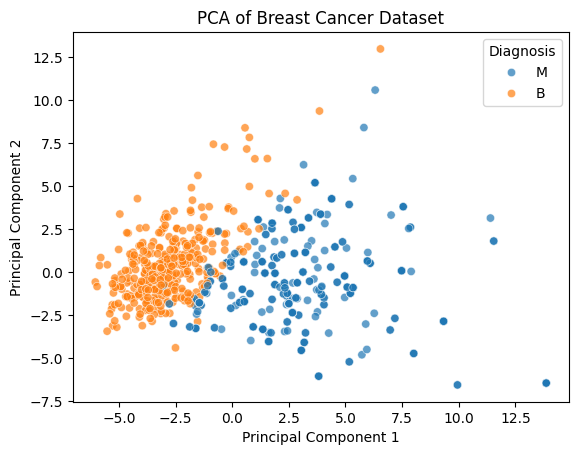

In [7]:
# Import PCA for dimensionality reduction
from sklearn.decomposition import PCA

# Apply PCA to the standardized features
pca_features = PCA(n_components=2).fit(features_scaled)

# Scatter plot the first two principal components with class legend using seaborn
sns.scatterplot(x=pca_features.transform(features_scaled)[:, 0], y=pca_features.transform(features_scaled)[:, 1], 
                hue=balanced_dataset_scaled['diagnosis'], alpha = 0.7, palette='tab10')
plt.title('PCA of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diagnosis')
plt.show()

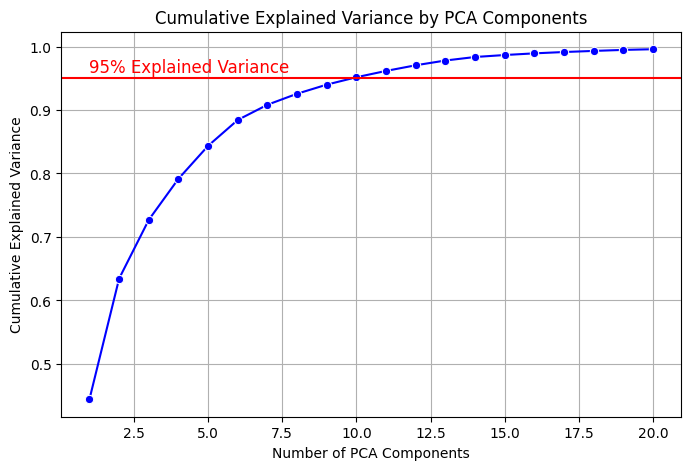

In [8]:
# Reduce dataset dimensionality using PCA for evaluation and visualization
from sklearn.decomposition import PCA

# Evaluate the optimal number of components using explained variance ratio
pca_eval = PCA(n_components=20, whiten=False) 
pca_eval.fit(features_scaled)

# Plot the explained variance ratio to determine the optimal number of components using seaborn lineplot
plt.figure(figsize=(8, 5))
cum_var = pca_eval.explained_variance_ratio_.cumsum()
sns.lineplot(x=range(1, len(cum_var) + 1), y=cum_var, marker='o', color='blue')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, '95% Explained Variance', color='red', fontsize=12)
plt.grid()

<Figure size 3200x800 with 0 Axes>

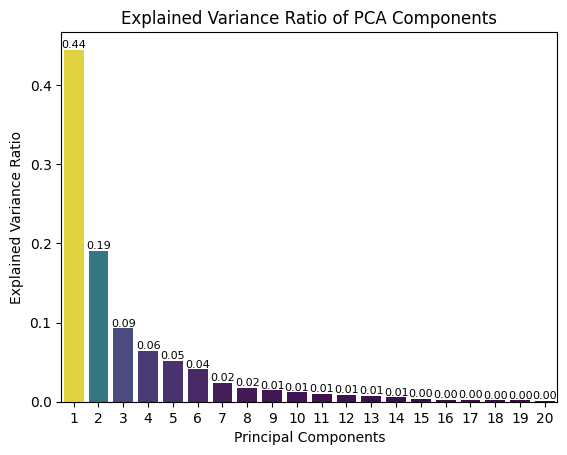

In [9]:
# Plot the explained variance ratio using seaborn barplot
plt.figure(figsize=(32, 8))
fig, ax = plt.subplots()
sns.barplot(x=[f'{i+1}' for i in range(len(pca_eval.explained_variance_ratio_))], 
            y=pca_eval.explained_variance_ratio_, palette='viridis', ax=ax, 
            hue=pca_eval.explained_variance_ratio_, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=8)
plt.title('Explained Variance Ratio of PCA Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

# Splitting Normal and Anomaly Data Samples
Anomaly detection in these datasets often employs one-class classification, where the model only learns the distribution of the "Normal" class (B - benign). 

In [10]:
# Filter the data samples for "B - benign" samples from the "M - malignant" class
benign_data = pca_features.transform(features_scaled)[targets.values == 'B']

# Extract features for "B - benign" samples
benign_features = pd.DataFrame(benign_data, columns=[f'PC{i+1}' for i in range(benign_data.shape[1])])

# Display 10 random benign features
benign_features.sample(10).style.hide(axis="index")

PC1,PC2
-0.332471,1.271314
-2.608030,1.519641
-2.989904,0.021292
-4.103002,-2.622138
-3.416668,-1.418907
-3.961529,1.532816
-4.861161,-0.422411
-1.803584,4.903132
0.678690,1.462760
-1.218975,-0.841524


In [11]:
# Filter the data samples for "M - malignant" samples from the "B - benign" class
malignant_data = pca_features.transform(features_scaled)[targets.values == 'M']

# Extract features for "M - malignant" samples
malignant_features = pd.DataFrame(malignant_data, columns=[f'PC{i+1}' for i in range(malignant_data.shape[1])])

# Display 10 random malignant features
malignant_features.sample(10).style.hide(axis="index")

PC1,PC2
13.864371,-6.462188
1.710801,-3.537524
-1.677790,-1.557155
7.899725,0.030545
1.441807,-0.065487
1.082315,0.960940
4.632495,-0.597952
2.657530,-2.367080
5.214378,-1.239337
3.121441,-0.004363


# Visualizing the Normal Distribution of the Data
Visualizing the normal distribution of tabular data involves creating a bell-shaped curve that represents data symmetry, center (mean), and spread (standard deviation). Key techniques include plotting a histogram with a kernel density estimation (KDE) curve.

A **histogram** is a data visualization tool that represents the frequency distribution of continuous or discrete numerical data using vertical bars. It groups data points into continuous ranges called "bins" or "intervals" on the x-axis, with the height of each bar showing the number of observations (frequency) in that range.

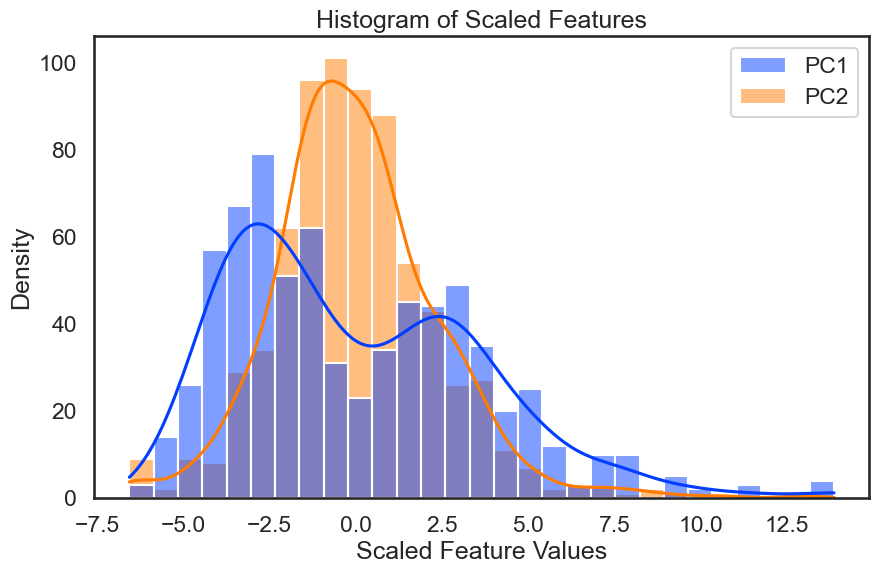

In [12]:
# Visualizing the normal distribution of tabular data involves creating a bell-shaped curve that 
# represents data symmetry, center (mean), and spread (standard deviation). Key techniques include 
# plotting a histogram with a kernel density estimation (KDE) curve.

# Set the seaborn style (optional, enhances visual appeal)
sns.set_theme(context='talk', style='white', palette='pastel')

# Create the histogram plot
plt.figure(figsize=(10, 6))

# Combine the two features into a single DataFrame for plotting
combined_features = pd.concat([benign_features, malignant_features], ignore_index=True)

# Plotting all features in one figure without any legend in the figure
sns.histplot(data=combined_features, kde=True, legend=True, palette='bright')
plt.title('Histogram of Scaled Features')
plt.xlabel('Scaled Feature Values')
plt.ylabel('Density')
plt.show()

# Train the Anomaly Detection Model
Anomaly detection models identify data points, events, or observations that deviate significantly from the dataset's normal behavior. EllipticEnvelope are all statistical, density-based methods that identify anomalies as data points with low probability or that fall outside a defined shape of "normal" data.

## GaussianMixture
This model assumes that the normal data is generated by a mixture of several Gaussian (normal) distributions. It uses the expectation-maximization (EM) algorithm to find the parameters (mean, covariance, and weight) of each component.

Points that have a low probability density under the fitted mixture model are flagged as anomalies. The anomaly score is typically the negative log of a data point.

## BayesianGaussianMixture
This is a more robust, non-parametric extension of the GaussianMixture model that uses Bayesian inference. A key advantage is that it can automatically determine the optimal number of Gaussian components from the data, rather than requiring it to be set manually.

 Similar to `GaussianMixture`, anomalies are identified as data points with low likelihood under the final, optimized mixture model.

 ## EllipticEnvelope
 This algorithm assumes that the regular data has a single Gaussian distribution and attempts to fit an imaginary ellipse (or hyper-ellipsoid in higher dimensions) that encloses the "normal" observations. It is a robust method that works by ignoring potential outliers when estimating the covariance matrix of the data using the Minimum Covariance Determinant (MCD) method.

 Data points that fall outside the defined elliptical area are classified as outliers.

In [13]:
# Training anomaly detection model using EllipticEnvelope
from sklearn.covariance import EllipticEnvelope

# Initialize the EllipticEnvelope model
elenv = EllipticEnvelope(contamination=0.15)

# Fit the model on the scaled benign features
elenv.fit(benign_features)

,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, the support of robust location and covariance estimatesis computed, and a covariance estimate is recomputed from it,without centering the data.Useful to work with data whose mean is significantly equal tozero but is not exactly zero.If False, the robust location and covariance are directly computedwith the FastMCD algorithm without additional treatment.",False
,"support_fraction support_fraction: float, default=NoneThe proportion of points to be included in the support of the rawMCD estimate. If None, the minimum value of support_fraction willbe used within the algorithm: `(n_samples + n_features + 1) / 2 * n_samples`.Range is (0, 1).",None
,"contamination contamination: float, default=0.1The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Range is (0, 0.5].",0.15
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the pseudo random number generator for shufflingthe data. Pass an int for reproducible results across multiple functioncalls. See :term:`Glossary `.",None


In [14]:
# Training anomaly detection model using GaussianMixture
from sklearn.mixture import GaussianMixture

# Initialize the GaussianMixture model
gmm = GaussianMixture(n_components=2, covariance_type='full')

# Fit the model on the scaled benign features
gmm.fit(benign_features)

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [15]:
# Training anomaly detection model using BayesianGaussianMixture
from sklearn.mixture import BayesianGaussianMixture

# Initialize the BayesianGaussianMixture model
bgmm = BayesianGaussianMixture(n_components=2, covariance_type='full')

# Fit the model on the scaled benign features
bgmm.fit(benign_features.astype('float32'))

,"n_components n_components: int, default=1The number of mixture components. Depending on the data and the valueof the `weight_concentration_prior` the model can decide to not useall the components by setting some component `weights_` to values veryclose to zero. The number of effective components is therefore smallerthan n_components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full' (each component has its own general covariance matrix),- 'tied' (all components share the same general covariance matrix),- 'diag' (each component has its own diagonal covariance matrix),- 'spherical' (each component has its own single variance).",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain on the likelihood (of the training data withrespect to the model) is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The result with the highestlower bound value on the likelihood is kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and thecovariances. String must be one of:- 'kmeans': responsibilities are initialized using kmeans.- 'k-means++': use the k-means++ method to initialize.- 'random': responsibilities are initialized randomly.- 'random_from_data': initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weight_concentration_prior_type weight_concentration_prior_type: {'dirichlet_process', 'dirichlet_distribution'}, default='dirichlet_process'String describing the type of the weight concentration prior.",'dirichlet_process'
,"weight_concentration_prior weight_concentration_prior: float or None, default=NoneThe dirichlet concentration of each component on the weightdistribution (Dirichlet). This is commonly called gamma in theliterature. The higher concentration puts more mass inthe center and will lead to more components being active, while a lowerconcentration parameter will lead to more mass at the edge of themixture weights simplex. The value of the parameter must be greaterthan 0. If it is None, it's set to ``1. / n_components``.",None
,"mean_precision_prior mean_precision_prior: float or None, default=NoneThe precision prior on the mean distribution (Gaussian).Controls the extent of where means can be placed. Largervalues concentrate the cluster means around `mean_prior`.The value of the parameter must be greater than 0.If it is None, it is set to 1.",None
,"mean_prior mean_prior: array-like, shape (n_features,), default=NoneThe prior on the mean distribution (Gaussian).If it is None, it is set to the mean of X.",None


In [47]:
import numpy as np

# Derive anomaly thresholds from the benign training distribution
# GMM/BGMM do not return anomaly labels from predict(); they return cluster IDs.
# We convert low-likelihood samples into anomalies using a percentile threshold.
gmm_benign_scores = gmm.score_samples(benign_features.astype('float32'))
bgmm_benign_scores = bgmm.score_samples(benign_features.astype('float32'))

# Match the EllipticEnvelope contamination rate for a fair comparison
anomaly_quantile = 0.15
gmm_threshold = np.quantile(gmm_benign_scores, anomaly_quantile)
bgmm_threshold = np.quantile(bgmm_benign_scores, anomaly_quantile)

print(f'GMM anomaly threshold (score_samples <= threshold): {gmm_threshold:.4f}')
print(f'BGMM anomaly threshold (score_samples <= threshold): {bgmm_threshold:.4f}')

GMM anomaly threshold (score_samples <= threshold): -4.8922
BGMM anomaly threshold (score_samples <= threshold): -4.8423


# Creating Test Set for Anomaly Detection Evaluation
The test set should contain a mix of known normal data (benign) and various types of known anomalous data (malignant) to properly evaluate model performance.

In [31]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# import label encoder for encoding the target variable
from sklearn.preprocessing import LabelEncoder

# Encode the target variable (diagnosis) to binary labels (0 for benign, 1 for malignant)
label_encoder = LabelEncoder()
targets_encoded = label_encoder.fit_transform(targets)

# Split data set to obtain test set (20%)
X, X_test, y, y_test = train_test_split(features, targets_encoded, test_size=0.20, shuffle=True, random_state=43, stratify=targets_encoded)

# Print the number of samples in each class
malignant_count = y_test[y_test == 1].shape[0]
benign_count = y_test[y_test == 0].shape[0]

# Create a dataframe for the class sample sizes
test_samples_df = pd.DataFrame({
    'Dataset Sample Size': [y.shape[0] + y_test.shape[0]],
    'Train Sample Size': [y.shape[0]],
    'Test Sample Size': [y_test.shape[0]],
    'Benign Test Size': [benign_count],
    'Malignant Test Size': [malignant_count]
})

# Display the distribution of the features for good and bad samples
test_samples_df.style.hide(axis="index")

Dataset Sample Size,Train Sample Size,Test Sample Size,Benign Test Size,Malignant Test Size
714,571,143,72,71


# Evaluating Anomaly Detection Models
Evaluating anomaly detection models requires a, multi-faceted approach focusing on **precision**, **recall**, and **F1-score** to handle imbalanced data, ensuring high detection rates for rare events while minimizing false positives. **Confusion** helps visualize where a model gets "confused" between normal and anomalous data, which is crucial given the often imbalanced nature of anomaly detection datasets.

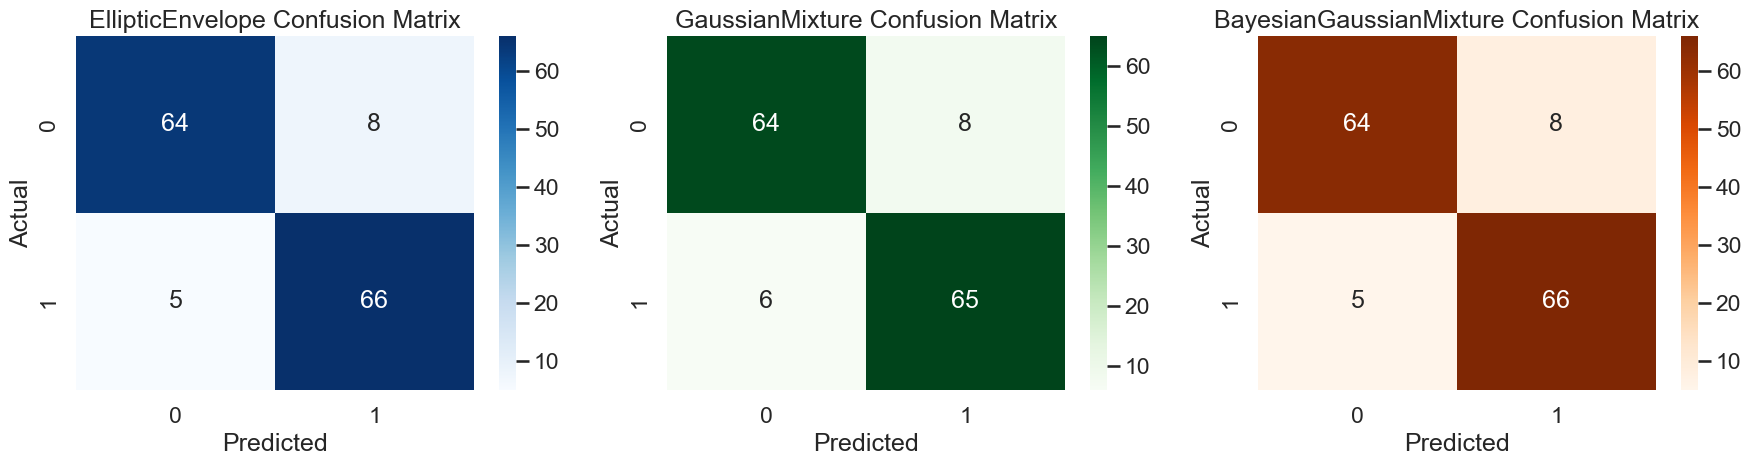

In [35]:
# Import numpy for array manipulation
import numpy as np

# Scale the test features using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# PCA transform the scaled test features using the fitted PCA model
X_test_pca = pca_features.transform(X_test_scaled)

# Concat the PCA transformed test features with PCA features names before evaluation
X_test_pca = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

# Evaluate the EllipticEnvelope model on the test set
y_pred_elenv = elenv.predict(X_test_pca)
y_pred_elenv = np.where(y_pred_elenv == 1, 0, 1)  # Convert to binary labels (0 for inliers, 1 for outliers)

# Evaluate the GaussianMixture model on the test set using likelihood thresholds
gmm_scores = gmm.score_samples(X_test_pca)
y_pred_gmm = (gmm_scores < gmm_threshold).astype(int)

# Evaluate the BayesianGaussianMixture model on the test set using likelihood thresholds
bgmm_scores = bgmm.score_samples(X_test_pca)
y_pred_bgmm = (bgmm_scores < bgmm_threshold).astype(int)

# Evaluate the performance of the models using confusion matrix
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix for EllipticEnvelope
cm_elenv = confusion_matrix(y_test, y_pred_elenv)

# Calculate confusion matrix for GaussianMixture
cm_gmm = confusion_matrix(y_test, y_pred_gmm)

# Calculate confusion matrix for BayesianGaussianMixture
cm_bgmm = confusion_matrix(y_test, y_pred_bgmm)

# Plot the confusion matrices using seaborn heatmap
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.heatmap(cm_elenv, annot=True, fmt='d', cmap='Blues')
plt.title('EllipticEnvelope Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1, 3, 2)
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Greens')
plt.title('GaussianMixture Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1, 3, 3)
sns.heatmap(cm_bgmm, annot=True, fmt='d', cmap='Oranges')
plt.title('BayesianGaussianMixture Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

The **ROC (Receiver Operating Characteristic)** curve is a crucial tool for evaluating anomaly detection models, particularly when labeled data is available. It visualizes the trade-off between the True Positive Rate (TPR) and the False Positive Rate (FPR) across various classification thresholds.

![Alt text](https://www.monolithai.com/hs-fs/hubfs/ROC%20curve%203%20model%20comparison.png?width=651&height=647&name=ROC%20curve%203%20model%20comparison.png)

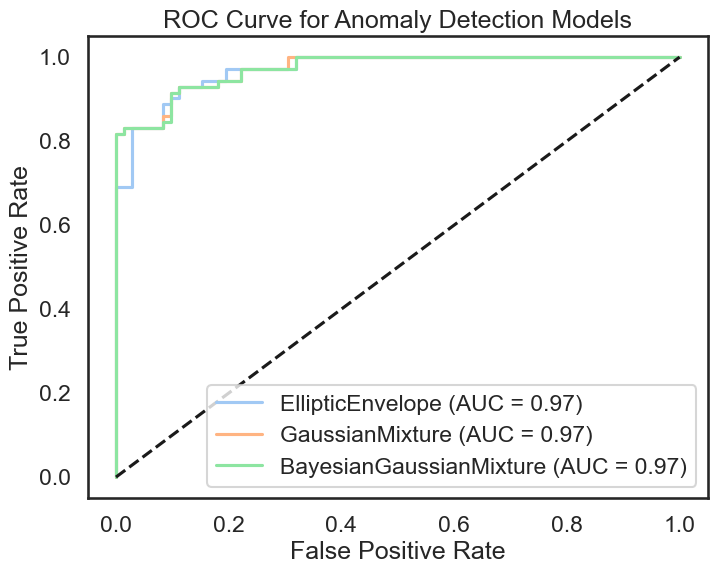

In [42]:
# Plot the ROC curve for each model
from sklearn.metrics import roc_curve, auc

# Compute decision function scores for EllipticEnvelope
y_scores_elenv = elenv.decision_function(X_test_pca)

# Compute ROC curve and AUC for EllipticEnvelope
fpr_elenv, tpr_elenv, _ = roc_curve(y_test, -y_scores_elenv)
auc_elenv = auc(fpr_elenv, tpr_elenv)

# Compute scores for GaussianMixture 
y_scores_gmm = gmm.score_samples(X_test_pca)
# Compute ROC curve and AUC for GaussianMixture
fpr_gmm, tpr_gmm, _ = roc_curve(y_test, -y_scores_gmm)
auc_gmm = auc(fpr_gmm, tpr_gmm)

# Compute scores for BayesianGaussianMixture
y_scores_bgmm = bgmm.score_samples(X_test_pca)

# Compute ROC curve and AUC for BayesianGaussianMixture
fpr_bgmm, tpr_bgmm, _ = roc_curve(y_test, -y_scores_bgmm)
auc_bgmm = auc(fpr_bgmm, tpr_bgmm)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_elenv, tpr_elenv, label=f'EllipticEnvelope (AUC = {auc_elenv:.2f})')
plt.plot(fpr_gmm, tpr_gmm, label=f'GaussianMixture (AUC = {auc_gmm:.2f})')
plt.plot(fpr_bgmm, tpr_bgmm, label=f'BayesianGaussianMixture (AUC = {auc_bgmm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.title('ROC Curve for Anomaly Detection Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Select Random Test Samples & Performe Prediction
To make predictions with a machine learning model on a random test set sample, you must first have a trained model and a preprocessed dataset that has been split into training and testing sets. You then use the model's ```predict()``` method on the features of your test data. 

In [65]:
# Import random module
import random as rnd

# Select random features from test set (X_test) for testing the model
random_index = rnd.randint(0, X_test.shape[0] - 1)
random_test_features = X_test[random_index:random_index + 1]
random_test_labels = y_test[random_index:random_index + 1]

# Print the random test features (CSV format) and their corresponding encoded label
print(f"Random Test Features (Raw):")
print(pd.DataFrame(random_test_features).to_csv(header=False, index=False).strip())

# Scaled the random test features using the fitted scaler
random_test_features = scaler.transform(random_test_features.astype('float32'))

# Transform the random test features using PCA for model prediction
random_test_features_pca = pca_features.transform(random_test_features.astype('float32'))

# Print the random test features in PCA space
print(f"Random Test Features (PCA): {pd.DataFrame(random_test_features_pca.astype('float32')).to_csv(header=False, index=False).strip()}")

print(f"Corresponding Encoded Label (0 - B, 1 - M): {random_test_labels[0]} - {label_encoder.inverse_transform(random_test_labels)[0]}")

Random Test Features (Raw):
12.05,22.72,78.75,447.8,0.06935,0.1073,0.07943,0.02978,0.1203,0.06659,0.1194,1.434,1.778,9.549,0.005042,0.0456,0.04305,0.01667,0.0247,0.007358,12.57,28.71,87.36,488.4,0.08799,0.3214,0.2912,0.1092,0.2191,0.09349
Random Test Features (PCA): -2.1078024,1.0285469
Corresponding Encoded Label (0 - B, 1 - M): 0 - B


In [66]:
# Create a DataFrame for the transformed test features in PCA space with appropriate column names
test_features_pca_df = pd.DataFrame(random_test_features_pca, columns=[f'PC{i+1}' for i in range(random_test_features_pca.shape[1])])

# Do prediction of sample test features using EllipticEnvelope model
y_pred_elenv_sample = elenv.predict(test_features_pca_df)

# Convert the predictions to binary labels (0 for inliers, 1 for outliers)
y_pred_elenv_sample = np.where(y_pred_elenv_sample == 1, 0, 1)

# Do prediction of sample test features using GaussianMixture model
# GMM predict() returns cluster IDs, so use score_samples() for anomaly detection.
gmm_score_sample = gmm.score_samples(test_features_pca_df.astype('float32'))[0]
y_pred_gmm_sample = int(gmm_score_sample < gmm_threshold)

# Do prediction of sample test features using BayesianGaussianMixture model
# BGMM predict() returns cluster IDs, so use score_samples() for anomaly detection.
bgmm_score_sample = bgmm.score_samples(test_features_pca_df.astype('float32'))[0]
y_pred_bgmm_sample = int(bgmm_score_sample < bgmm_threshold)

# Compute EllipticEnvelope distance score for the random test sample
elenv_distance = elenv.mahalanobis(test_features_pca_df)

# Create a dataframe displaying the prediction results for each model along with the actual label for the random test sample
prediction_results_df = pd.DataFrame({
    'Model': ['EllipticEnvelope', 'GaussianMixture', 'BayesianGaussianMixture'],
    'Prediction': [
        label_encoder.inverse_transform(y_pred_elenv_sample)[0],
        label_encoder.inverse_transform([y_pred_gmm_sample])[0],
        label_encoder.inverse_transform([y_pred_bgmm_sample])[0]
    ],
    'Actual Label': [label_encoder.inverse_transform(random_test_labels)[0]] * 3,
    'Dist./Score:': [elenv_distance[0], gmm_score_sample, bgmm_score_sample],
    'Threshold:': [None, gmm_threshold, bgmm_threshold]
})

# Display the prediction results
prediction_results_df.style.hide(axis="index")

Model,Prediction,Actual Label,Dist./Score:,Threshold:
EllipticEnvelope,B,B,0.551148,nan
GaussianMixture,B,B,-2.913775,-4.892154
BayesianGaussianMixture,B,B,-2.859837,-4.842290


# Visualizing Decision Boundaries
Anomaly detection decision boundaries are thresholds or shapes such as hyperplanes or hyperspheres that delineate normal data from anomalies in feature space. These boundaries are typically learned in an unsupervised or semi-supervised manner, often maximizing the distance around normal data, where points falling outside the boundary are classified as anomalies.

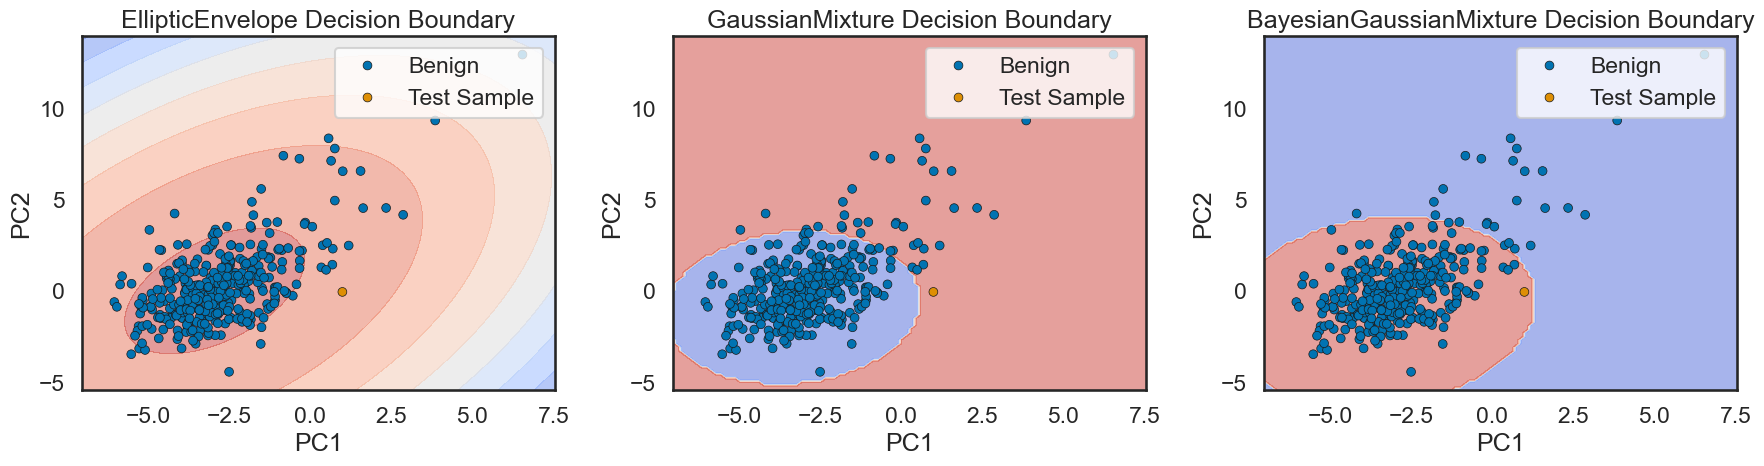

In [23]:
# Import the DecisionBoundaryDisplay from scikit-learn
from sklearn.inspection import DecisionBoundaryDisplay

# Compute the decision boundary for each model using DecisionBoundaryDisplay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define model names for titles
model_names = ["EllipticEnvelope", "GaussianMixture", "BayesianGaussianMixture"]

# Combine the benign features and the test features for plotting
combined_features = pd.concat([benign_features, test_features_pca_df], ignore_index=True)

# Plot the decision boundary for each model and overlay the combined features
for i, (model_name, clf) in enumerate(zip(model_names, [elenv, gmm, bgmm])):
    # if model is EllipticEnvelope, use the "decision_function" for the response method; otherwise, use "score_samples"
    if model_name == "EllipticEnvelope":
        response_method = "decision_function"
    else:
        response_method = "predict"
    
    # Plot the decision boundary using DecisionBoundaryDisplay
    DecisionBoundaryDisplay.from_estimator(
        clf,
        combined_features,
        response_method=response_method,
        plot_method="contourf",
        cmap="coolwarm",
        alpha=0.5,
        ax=axes[i],
    )

    sns.scatterplot(
        x=combined_features["PC1"],
        y=combined_features["PC2"],
        hue=['Benign'] * len(benign_features) + ['Test Sample'] * len(test_features_pca_df),
        palette="colorblind",
        ax=axes[i],
        edgecolor="k",
        s=40,
        legend=True,
    )
    
    axes[i].set_title(f"{model_name} Decision Boundary")
    axes[i].legend(loc="upper right")
    
plt.tight_layout()
plt.show()


## micromlgen - Machine Learning for Tiny Embedded Systems
**micromlgen** is a Python library that bridges the gap between traditional data science and embedded systems. It translates trained scikit-learn machine learning classifiers into lightweight, plain C/C++ code. This enables developers to easily deploy predictive models directly onto highly resource-constrained microcontrollers like Arduino, ESP32, or STM32.

Use the ```micromlgen.port()``` function to convert your model's weights and decision rules into a single ```.h``` or ```.c``` file.

You can install the package directly using Python's pip tool:
```bash
pip install micromlgen
```

In [24]:
# Generate C code for the PCA dimensionality reduction using micromlgen
from micromlgen import port

# Generate C code for the PCA dimensionality reduction
pca_c_code = port(pca_features, classmap={0: 'PC1', 1: 'PC2'}, function_name='pca_transform')

# Print the generated C code
print(pca_c_code)

# Generate .h header file for the PCA
with open('PCA.h', 'w') as f:
    f.write(pca_c_code)

#pragma once
#include <cstdarg>
namespace Eloquent {
    namespace ML {
        namespace Port {
            class PCA {
                public:
                    /**
                    * Apply dimensionality reduction
                    * @warn Will override the source vector if no dest provided!
                    */
                    void transform(float *x, float *dest = NULL) {
                        static float u[2] = { 0 };
                        u[0] = dot(x,   0.222021605934  , 0.112753989015  , 0.230366060381  , 0.222197826014  , 0.145657751759  , 0.238690561681  , 0.259126316452  , 0.260486575977  , 0.138850481399  , 0.055933795508  , 0.20805887579  , 0.022374545325  , 0.214122051796  , 0.199201050479  , 0.021645281353  , 0.172166715012  , 0.15792201558  , 0.186773333102  , 0.039266121609  , 0.102509110879  , 0.227354106767  , 0.108081743968  , 0.237028373238  , 0.222021054241  , 0.126480243762  , 0.205644017915  , 0.228470521456  , 0.250857718156  , 0.107110513347

## emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use 
```bash
pip install emlearn
```

In [25]:
# Import emlearn for model conversion
import emlearn

# Convert Anamaly Detection models to C code using emlearn
c_code_elenv = emlearn.convert(elenv, method='inline', dtype='float')
c_code_gmm = emlearn.convert(gmm, method='inline', dtype='float')
c_code_bgmm = emlearn.convert(bgmm, method='inline', dtype='float')

# Save the generated C code to a file
c_code_elenv.save(file='EllipticEnvelope.h', name='EllipticEnvelope')
c_code_gmm.save(file='GaussianMixture.h', name='GaussianMixture')
c_code_bgmm.save(file='BayesianGaussianMixture.h', name='BayesianGaussianMixture')

'\n    // !! This file was generated using emlearn\n\n    #include <eml_mixture.h>\n    \nstatic const float BayesianGaussianMixture_means[4] = { -0.658387f, 3.767312f, -3.034029f, -0.038192f };\nstatic const float BayesianGaussianMixture_precisions[8] = { 0.416996f, -0.421904f, 0.000000f, 0.453539f, 0.791697f, -0.323997f, 0.000000f, 0.724171f };\nstatic const float BayesianGaussianMixture_log_weights[2] = { -2.328399f, -0.120810f };\nstatic const float BayesianGaussianMixture_log_dets[2] = { -1.665353f, -0.556304f };\nEmlMixtureModel BayesianGaussianMixture_model = { 2, 2, EmlCovarianceFull, BayesianGaussianMixture_means, BayesianGaussianMixture_precisions, BayesianGaussianMixture_log_dets, BayesianGaussianMixture_log_weights };\n\n\n        int32_t\n        BayesianGaussianMixture_predict_log_proba(const float values[], int32_t values_length, float *out)\n        {\n\n            return eml_mixture_predict_log_proba(&BayesianGaussianMixture_model,\n                                val